### Surface energy



The easiest way to calculate surface energies is from this equation:

$\sigma = \frac{1}{2}(E_{slab} - \frac{N_{slab}}{N_{bulk}} E_{bulk})$

where $E_{slab}$ is the total energy of a symmetric slab (i.e. one with inversion symmetry, and where both sides of the slab have been relaxed), $E_{bulk}$ is the total energy of a bulk unit cell, $N_{slab}$ is the number of atoms in the slab, and $N_{bulk}$ is the number of atoms in the bulk unit cell. One should be sure that the bulk energy is fully converged with respect to $k$-points, and that the slab energy is also converged with respect to $k$-points. The energies should be compared at the same cutoff energies. The idea is then to increase the thickness of the slab until the surface energy $\sigma$ converges.

![img](./images/surface-construction.png "Schematic figure illustrating the calculation of a surface energy.")

Unfortunately, this approach does not always work. The bulk system is treated subtly different than the slab system, particularly in the $z$-direction where the vacuum is (where typically only one $k$-point is used in slabs). Consequently, the $k$-point sampling is not equivalent in the two systems, and one can in general expect some errors due to this, with the best case being cancellation of the errors due to total $k$-point convergence. In the worst case, one can get a linear divergence in the surface energy with slab thickness cite:PhysRevB.49.16798.

A variation of this method that usually results in better $k$-point error cancellation is to calculate the bulk unit cell energy using the slab unit cell with no vacuum space, with the same $k$-point mesh in the $x$ and $y$ directions, but with increased $k$-points in the $z$-direction. Thus, the bulk system and slab system have the same Brillouin zone in at least two dimensions. This maximizes the cancellation of $k$-point errors, but still does not guarantee convergence of the surface energy, as discussed in cite:PhysRevB.49.16798,0953-8984-10-4-017.

For quick estimates of the surface energy, one of the methods described above is likely sufficient. The advantage of these methods is the small number of calculations required to obtain the estimate, one needs only a bulk calculation (which must be done anyhow to get the bulk lattice constant to create the slab), and a slab calculation that is sufficiently thick to get the estimate. Additional calculations are only required to test the convergence of the surface energy.

An alternative method for calculating surface energies that does not involve an explicit bulk calculation follows Ref. cite:0953-8984-10-4-017. The method follows from equation (ref{eq:se}) where for a N-atom slab, in the limit of N &rarr; &infin;,

$E_{slab} \approx 2\sigma + \frac{N_{slab}}{N_{bulk}} E_{bulk}$

Then, we can estimate E<sub>bulk</sub> by plotting the total energy of the slab as a function of the slab thickness.

$\sigma = \lim_{N \rightarrow \infty} \frac{1}{2}(E_{slab}^N - N \Delta E_N)$

where $\Delta E_N = E_{slab}^N - E_{slab}^{N-1}$.

We will examine this approach here. We will use unrelaxed slabs for computational efficiency.



/opt/conda/lib/python3.9/site-packages/ase/lattice/surface.py:17: UserWarning: Moved to ase.build
  warnings.warn('Moved to ase.build')


nlayers =  3 sigma = 0.561 eV/atom
nlayers =  4 sigma = 0.398 eV/atom
nlayers =  5 sigma = 0.595 eV/atom
nlayers =  6 sigma = 0.308 eV/atom
nlayers =  7 sigma = 0.590 eV/atom
nlayers =  8 sigma = 0.332 eV/atom
nlayers =  9 sigma = 0.591 eV/atom
nlayers = 10 sigma = 0.391 eV/atom


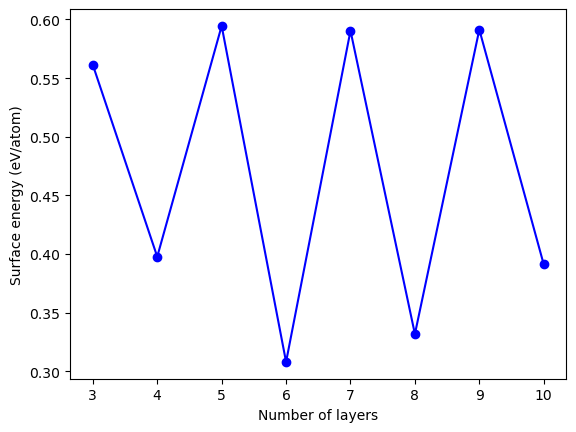

In [1]:
from vasp import Vasp
from ase.lattice.surface import fcc111
import matplotlib.pyplot as plt

Nlayers = [3, 4, 5, 6, 7, 8, 9, 10, 11]
energies = []
sigmas = []

for n in Nlayers:
    slab = fcc111('Cu', size=(1, 1, n), vacuum=10.0)
    slab.center()

    calc = Vasp(f'bulk/Cu-layers/{n}',
                xc='PBE',
                encut=350,
                kpts=(8, 8, 1),
                atoms=slab)
    energies.append(calc.get_potential_energy())

for i in range(len(Nlayers) - 1):
    N = Nlayers[i]
    DeltaE_N = energies[i + 1] - energies[i]
    sigma = 0.5 * (-N * energies[i + 1] + (N + 1) * energies[i])
    sigmas.append(sigma)
    print(f'nlayers = {N:2d} sigma = {sigma:1.3f} eV/atom')

plt.plot(Nlayers[0:-1], sigmas, 'bo-')
plt.xlabel('Number of layers')
plt.ylabel('Surface energy (eV/atom)')
plt.show()

    nlayers =  3 sigma = 0.561 eV/atom
    nlayers =  4 sigma = 0.398 eV/atom
    nlayers =  5 sigma = 0.594 eV/atom
    nlayers =  6 sigma = 0.308 eV/atom
    nlayers =  7 sigma = 0.590 eV/atom
    nlayers =  8 sigma = 0.332 eV/atom
    nlayers =  9 sigma = 0.591 eV/atom
    nlayers = 10 sigma = 0.392 eV/atom

![img](./images/Cu-unrelaxed-surface-energy.png "Surface energy of a Cu(111) slab as a function of thickness.")

One reason for the oscillations may be quantum size effects cite:Fiolhais2003209. In citealp:PhysRevB.75.115131 the surface energy of Cu(111) is reported as 0.48 eV/atom, or 1.36 J/m$^2$. Here is an example showing a conversion between these two units. We use ase to compute the area of the unit cell from the norm of the cross-product of the vectors defining the surface unit cell.



In [2]:
from ase.lattice.surface import fcc111
from ase.units import J, m
import numpy as np

slab = fcc111('Cu', size=(1, 1, 3), vacuum=10.0)
cell = slab.get_cell()

area = np.linalg.norm(np.cross(cell[0], cell[1]))  # area per atom

sigma = 0.48  # eV/atom

print(f'sigma = {sigma / area / (J / m**2)} J/m^2')

sigma = 1.3628140041526338 J/m^2


    sigma = 1.36281400415 J/m^2



#### Advanced topics in surface energy



The surface energies can be used to estimate the shapes of nanoparticles using a Wulff construction. See citealp:doi.10.1021/jp200950a for an example of computing Mo<sub>2</sub>C surface energies and particle shapes, and cite:Inoglu2009188 for an example of the influence of adsorbates on surface energies and particle shapes of Cu.

For a classic paper on trends in surface energies see cite:Vitos1998186.

